# 선형 회귀 한번 더
이전에는 선형 회귀를 한번더 작업해보려 합니다. 

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

mpg = fetch_ucirepo(id=9)

df = pd.concat((
    mpg.data.features,
    mpg.data.targets
), axis=1)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.0 KB
None


In [2]:
# 결측치 제거 
df = df.dropna(axis=0)
df.isna().sum()

displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

In [3]:
df.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,194.411990,5.471939,104.469388,2977.584184,15.541327,75.979592,1.576531,23.445918
std,104.644004,1.705783,38.491160,849.402560,2.758864,3.683737,0.805518,7.805007
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,105.000000,4.000000,75.000000,2225.250000,13.775000,73.000000,1.000000,17.000000
50%,151.000000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,22.750000
75%,275.750000,8.000000,126.000000,3614.750000,17.025000,79.000000,2.000000,29.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


In [4]:
df = pd.get_dummies(
    df,
    columns=["origin"],
    drop_first=True
)

In [8]:
df[["origin_2", "origin_3"]].drop_duplicates()

,origin_2,origin_3
0,False,False
14,False,True
19,True,False


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["mpg"]), df["mpg"],
    test_size=0.2,
    random_state=42
)

X_train.info(), y_train.info()

<class 'pandas.DataFrame'>
Index: 313 entries, 260 to 103
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  313 non-null    float64
 1   cylinders     313 non-null    int64  
 2   horsepower    313 non-null    float64
 3   weight        313 non-null    int64  
 4   acceleration  313 non-null    float64
 5   model_year    313 non-null    int64  
 6   origin_2      313 non-null    bool   
 7   origin_3      313 non-null    bool   
dtypes: bool(2), float64(3), int64(3)
memory usage: 17.7 KB
<class 'pandas.Series'>
Index: 313 entries, 260 to 103
Series name: mpg
Non-Null Count  Dtype  
--------------  -----  
313 non-null    float64
dtypes: float64(1)
memory usage: 4.9 KB


(None, None)

In [18]:
numeric_values = X_train.drop(columns=["origin_2", "origin_3"])
q1 = numeric_values.quantile(0.25) # Series
q3 = numeric_values.quantile(0.75) # Series
iqr = q3 - q1 # Series

high = q3 + 1.5 * iqr

low = q1 - 1.5 * iqr

# iqr_outlier = pd.concat((
#     high,
#     low
# ), axis=1).T.rename(index={0: "upper", 1: "lower"})

iqr_clean_df = numeric_values[(low < numeric_values)
                  & (numeric_values < high)]

iqr_clean_df
iqr_clean_df[["origin_2", "origin_3"]] = X_train[["origin_2", "origin_3"]]

iqr_clean_df = iqr_clean_df.dropna(axis=0)
iqr_clean_df.info()


<class 'pandas.DataFrame'>
Index: 304 entries, 260 to 103
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  304 non-null    float64
 1   cylinders     304 non-null    int64  
 2   horsepower    304 non-null    float64
 3   weight        304 non-null    int64  
 4   acceleration  304 non-null    float64
 5   model_year    304 non-null    int64  
 6   origin_2      304 non-null    bool   
 7   origin_3      304 non-null    bool   
dtypes: bool(2), float64(3), int64(3)
memory usage: 17.2 KB


In [25]:
iqr_clean_df.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin_2,origin_3
260,225.0,6,110.0,3620,18.7,78,False,False
184,140.0,4,92.0,2572,14.9,76,False,False
174,171.0,6,97.0,2984,14.5,75,False,False
64,318.0,8,150.0,4135,13.5,72,False,False
344,86.0,4,64.0,1875,16.4,81,False,False


# 원 핫 인코딩 하기
`pandas`의 `get_dummies()`메서드를 통해 `[1, 2, 3]`을 가진 범주형 데이터인 `origin`을 전처리 할 것입니다.

In [27]:
# 표준화
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

scale_columns = iqr_clean_df.columns.difference(["origin_2", "origin_3"])

scaled_iqr_clean_df = iqr_clean_df.copy()

scaled_iqr_clean_df[scale_columns] = scaler.fit_transform(
    iqr_clean_df[scale_columns]
)

scaled_iqr_clean_df.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin_2,origin_3
260,0.332132,0.329111,0.207991,0.784811,1.200936,0.473247,False,False
184,-0.521572,-0.861957,-0.309340,-0.475196,-0.256334,-0.087638,False,False
174,-0.210221,0.329111,-0.165637,0.020150,-0.409731,-0.368081,False,False
64,1.266185,1.520178,1.357615,1.403994,-0.793223,-1.209410,False,False
344,-1.063926,-0.861957,-1.114076,-1.313197,0.318904,1.314576,False,False


In [29]:
scaled_iqr_clean_df[scale_columns].corr()

,acceleration,cylinders,displacement,horsepower,model_year,weight
acceleration,1.000000,-0.459849,-0.484786,-0.654690,0.267419,-0.369590
cylinders,-0.459849,1.000000,0.956837,0.853447,-0.342542,0.893311
displacement,-0.484786,0.956837,1.000000,0.887031,-0.354281,0.937068
horsepower,-0.654690,0.853447,0.887031,1.000000,-0.399280,0.878162
model_year,0.267419,-0.342542,-0.354281,-0.399280,1.000000,-0.304528
weight,-0.369590,0.893311,0.937068,0.878162,-0.304528,1.000000


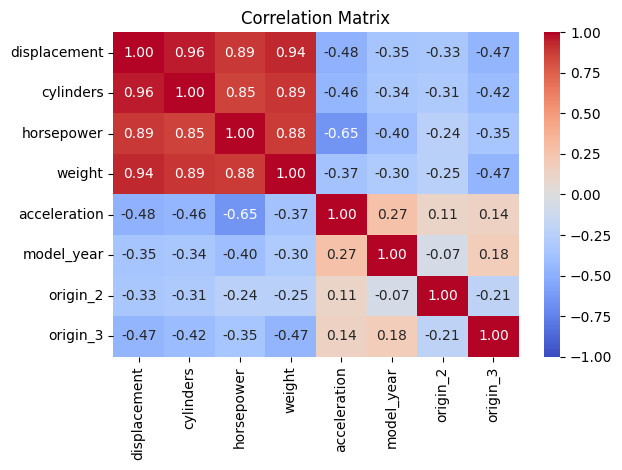

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    scaled_iqr_clean_df.corr(),
    annot=True, # 각 칸에 숫자 표시
    fmt=".2f", # 소수점 포멧
    cmap="coolwarm", # 색깔
    vmin=-1, # 색상 범위 최솟값
    vmax=1, # 색상 범위 최댓값
    center=0 # 값 0을 색상표의 중앙으로 설정
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

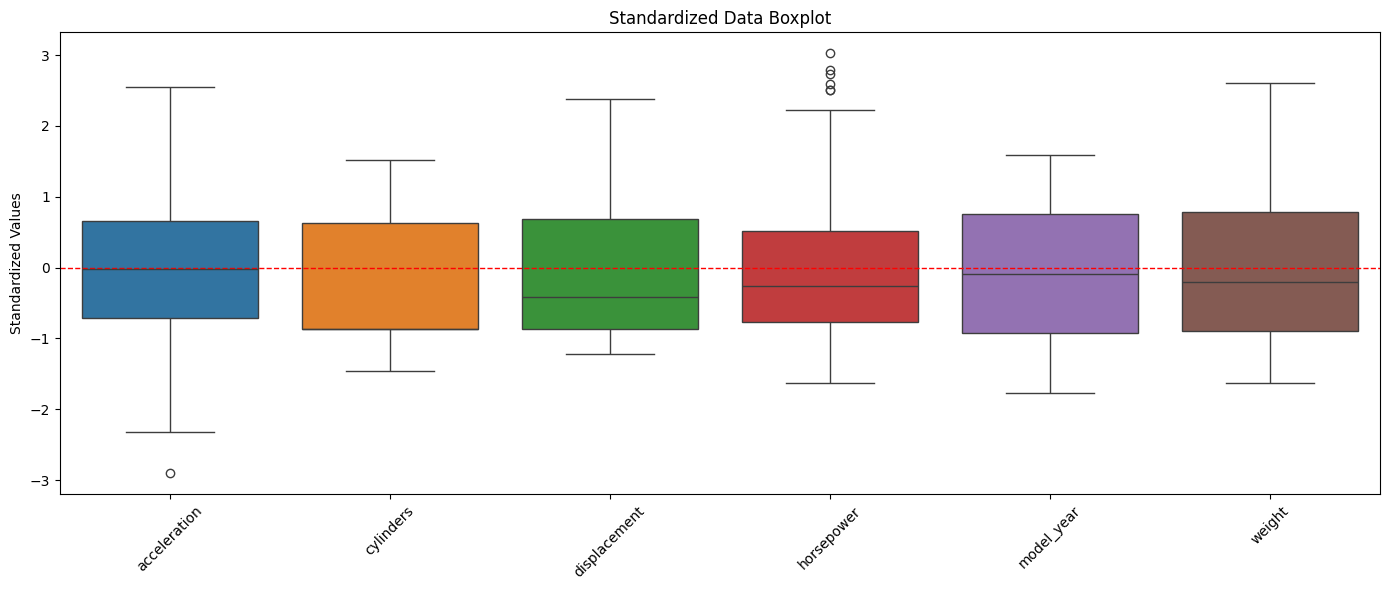

In [35]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=scaled_iqr_clean_df[scale_columns]
)

plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xticks(rotation=45)
plt.title("Standardized Data Boxplot")
plt.ylabel("Standardized Values")
plt.tight_layout()
plt.show()

In [10]:
scaled_iqr_clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  372 non-null    float64
 1   cylinders     372 non-null    float64
 2   horsepower    372 non-null    float64
 3   weight        372 non-null    float64
 4   acceleration  372 non-null    float64
 5   model_year    372 non-null    float64
 6   origin        372 non-null    float64
 7   mpg           372 non-null    float64
dtypes: float64(8)
memory usage: 23.4 KB


In [37]:
scaled_iqr_clean_df.info()

<class 'pandas.DataFrame'>
Index: 304 entries, 260 to 103
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  304 non-null    float64
 1   cylinders     304 non-null    float64
 2   horsepower    304 non-null    float64
 3   weight        304 non-null    float64
 4   acceleration  304 non-null    float64
 5   model_year    304 non-null    float64
 6   origin_2      304 non-null    bool   
 7   origin_3      304 non-null    bool   
dtypes: bool(2), float64(6)
memory usage: 25.3 KB


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

model = LinearRegression()

print("\n --- 학습 시작 --- \n")
model.fit(scaled_iqr_clean_df, y_train.loc[scaled_iqr_clean_df.index])
print("\n --- 학습 끝 --- \n")


 --- 학습 시작 --- 


 --- 학습 끝 --- 



In [48]:


X_test_scaled = X_test.copy()

X_test_scaled[scale_columns] = scaler.transform(
    X_test[scale_columns]
)

X_test_scaled.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin_2,origin_3
79,-0.871241,-0.82869,-0.890031,-0.857193,0.983005,-0.819292,True,False
276,-0.639606,-0.82869,0.280571,-0.168937,0.067515,0.778834,True,False
248,-0.917568,-0.82869,-1.119062,-1.298994,0.346143,0.778834,False,True
56,-0.917568,-0.82869,-0.864583,-1.122955,1.978103,-1.085647,False,False
393,-0.463563,-0.82869,-0.457417,-0.174616,0.027712,1.844251,False,False


In [51]:
print("\n --- 학습 후 테스트 --- \n")
print("R²:", model.score(X_test_scaled, y_test))
print("\n --- 수식 --- \n")
print("mpg = ", end="")
for col, coef in zip(X_test_scaled.columns, model.coef_):
    print(f"{col}*{coef} + ", end="")
print(f"{model.intercept_}")


 --- 학습 후 테스트 --- 

R²: 0.7735650461510876

 --- 수식 --- 

mpg = displacement*1.471061925990967 + cylinders*-0.21078999314394586 + horsepower*-1.332726764290138 + weight*-4.972602559190475 + acceleration*-0.11506284891867058 + model_year*2.774054419428815 + origin_2*2.5895695407677635 + origin_3*3.1512752709625182 + 22.680720488798727
